# Charting Boulder : Minimum Wage and Affordabiltiy

Brian C. Keegan, Ph.D.  
April 2026  
MIT License

Analyzes the gap between restaurant-industry wage claims and what tipped workers
actually earn, set against Boulder County's rent trajectory.

**Data sources:**
- U.S. Census Bureau — ACS 1-Year Estimates (median rent, housing cost burden, occupational earnings)
- U.S. Census Bureau — County Business Patterns (food service establishments & employment)
- HUD — Fair Market Rents historical file (1983–2026)
- Zillow — Observed Rent Index, Boulder metro (ZORI)
- Colorado / Boulder minimum wage schedule (City of Boulder ordinances)

**Key policy context:**  
Boulder City Council is weighing four options on the tipped wage offset,
ranging from maintaining the current approach to freezing tipped pay through 2029.


## 0. Imports & Setup

In [2]:
import urllib.request, io, json, warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

C_RENT   = "#2166ac"
C_TIPPED = "#d73027"
C_FULL   = "#4dac26"
C_CLAIM  = "#f46d43"
C_ACTUAL = "#1a9641"
C_GRAY   = "#7f7f7f"

def fetch(url, label=""):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    r   = urllib.request.urlopen(req, timeout=30)
    if label:
        print(f"  {label}")
    return r.read()

print("Setup complete.")

Setup complete.


In [8]:
acs_years = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024]

## 1. Boulder Minimum Wage & Tipped Wage Schedule

Hardcoded from City of Boulder ordinances and Colorado CDLE records. Boulder adopted its local minimum wage in 2020; prior years reflect the Colorado state minimum wage. The tip offset (the amount by which employers may pay tipped workers below the full minimum wage) has been \\$3.02 under both state and city policy — and stays at \\$3.02 under Option A (status quo).


In [2]:
# Boulder minimum wage history — City of Boulder ordinances + Colorado CDLE
# (year): (full_min_wage, tipped_min_wage, tip_offset)
mw_data = {
    2015: (8.23,  5.21, 3.02),
    2016: (8.31,  5.29, 3.02),
    2017: (9.30,  6.28, 3.02),
    2018: (10.20, 7.18, 3.02),
    2019: (11.10, 8.08, 3.02),
    2020: (12.00, 8.98, 3.02),
    2021: (12.32, 9.30, 3.02),
    2022: (12.56, 9.54, 3.02),
    2023: (13.65, 10.63, 3.02),
    2024: (14.42, 11.40, 3.02),
    2025: (16.82, 13.80, 3.02),   # current
    2026: (18.17, 15.15, 3.02),   # scheduled (Option A / no change)
}

mw = pd.DataFrame(mw_data, index=["full_min_wage", "tipped_min_wage", "tip_offset"]).T
mw.index.name = "year"
mw["annual_full"]   = mw["full_min_wage"]  * 2080
mw["annual_tipped"] = mw["tipped_min_wage"] * 2080

print(mw[["full_min_wage", "tipped_min_wage", "tip_offset"]].to_string())

      full_min_wage  tipped_min_wage  tip_offset
year                                            
2015           8.23             5.21        3.02
2016           8.31             5.29        3.02
2017           9.30             6.28        3.02
2018          10.20             7.18        3.02
2019          11.10             8.08        3.02
2020          12.00             8.98        3.02
2021          12.32             9.30        3.02
2022          12.56             9.54        3.02
2023          13.65            10.63        3.02
2024          14.42            11.40        3.02
2025          16.82            13.80        3.02
2026          18.17            15.15        3.02


## 2. Council's Four Policy Scenarios (2025–2030)

Project tipped wages under each option the council advanced on April 2, 2026.
Full minimum wage growth post-2026 is assumed at +3.5%/yr (near CPI).
Colorado law caps the tip offset at 25% of the full minimum wage.


In [3]:
full_wages = {
    2025: 16.82,
    2026: 18.17,
    2027: 18.81,
    2028: 19.47,
    2029: 20.15,
    2030: 20.86,
}

BASE_OFFSET      = 3.02   # current state-floor tip offset
MAX_OFFSET_SHARE = 0.25   # Colorado law cap (25% of full wage)

def scenario_tipped(full_wages, option):
    # A: keep offset flat at $3.02
    # B: scale offset proportionally with full wage from 2025 base
    # C: freeze tipped wage at $13.80 through 2029, then B-style growth
    # D: offset = 20% of full wage
    results = {}
    for yr, fw in full_wages.items():
        if option == "A":
            offset = BASE_OFFSET
        elif option == "B":
            scale  = fw / full_wages[2025]
            offset = BASE_OFFSET * scale
        elif option == "C":
            if yr <= 2029:
                offset = fw - 13.80   # freeze tipped at $13.80
            else:
                base_2029 = full_wages[2029] - 13.80
                offset    = base_2029 * (fw / full_wages[2029])
        elif option == "D":
            offset = fw * 0.20
        offset = min(offset, fw * MAX_OFFSET_SHARE)
        results[yr] = {
            "full":   fw,
            "offset": round(offset, 2),
            "tipped": round(fw - offset, 2),
        }
    return pd.DataFrame(results).T

scenarios = {lbl: scenario_tipped(full_wages, lbl) for lbl in ["A","B","C","D"]}
labels = {
    "A": "Option A: Keep current offset ($3.02)",
    "B": "Option B: Scale offset with full wage",
    "C": "Option C: Freeze tipped through 2029",
    "D": "Option D: Offset = 20% of full wage",
}
scenario_colors = {"A": "#4dac26", "B": "#756bb1", "C": "#d73027", "D": "#d9b838"}

print("Projected tipped wages by scenario ($/hr):")
comp = pd.DataFrame({lbl: sc["tipped"] for lbl, sc in scenarios.items()})
comp.index.name = "year"
comp["full_wage"] = pd.Series(full_wages)
print(comp.round(2).to_string())

print("\nAnnual equivalent at tipped wage (2080 hrs):")
ann = (comp.drop(columns="full_wage") * 2080).round(0).astype(int)
print(ann.to_string())

Projected tipped wages by scenario ($/hr):
          A      B      C      D  full_wage
year                                       
2025  13.80  13.80  13.80  13.46      16.82
2026  15.15  14.91  13.80  14.54      18.17
2027  15.79  15.43  14.11  15.05      18.81
2028  16.45  15.97  14.60  15.58      19.47
2029  17.13  16.53  15.11  16.12      20.15
2030  17.84  17.11  15.64  16.69      20.86

Annual equivalent at tipped wage (2080 hrs):
          A      B      C      D
year                            
2025  28704  28704  28704  27997
2026  31512  31013  28704  30243
2027  32843  32094  29349  31304
2028  34216  33218  30368  32406
2029  35630  34382  31429  33530
2030  37107  35589  32531  34715


## 2b. Option E — Councilmember Benjamin's Modified 2a

Source: Boulder Council Hotline email, March 30, 2026 (public record, Item 7A).

Benjamin proposes a freeze at \\$13.80/hr with a sunset by Jan 1, 2029.
His email math: full MW \\$18.17 − tipped \\$13.80 = offset \\$4.37.

**Two interpretations of "beginning January 1, 2027":**

- **E1 — Strict** (implied by Benjamin's own math): the freeze *prevents* the
  scheduled 2026 increase to \\$15.15. Tipped stays at \\$13.80 while the full
  MW rises to \\$18.17. Offset grows from \\$3.02 → \\$4.37. This is the only
  interpretation consistent with his stated "no worker earns less than today"
  because freezing at \\$13.80 *after* a rise to \\$15.15 would be a pay cut.

- **E2 — Lenient**: the 2026 scheduled increase to \\$15.15 happens per current
  policy. Then from Jan 1, 2027, the freeze holds tipped at \\$15.15.
  Contradicts Benjamin's \\$4.37 offset math but more worker-friendly.

**Post-sunset (Jan 1, 2029):** two paths modeled for each interpretation:
- **Path a** (no catch-up): tipped resumes growing from the frozen level at
  the same dollar increment Option A applies from 2029 onward.
- **Path b** (full catch-up): tipped jumps to where Option A would have been —
  best case for workers, requires political will to deliver.


In [4]:
# ── Option E: Benjamin's Modified 2a ─────────────────────────────────────────
# Source: Council Hotline email, March 30 2026 (public record)

# Extend full MW projection to 2032 for post-sunset visibility
full_wages_ext = dict(full_wages)
full_wages_ext[2031] = round(full_wages[2030] * 1.035, 2)
full_wages_ext[2032] = round(full_wages_ext[2031] * 1.035, 2)
years_ext = sorted(full_wages_ext.keys())

# Option A reference values for post-sunset increments
a_2028 = scenarios['A'].loc[2028, 'tipped']  # $16.45
a_2029 = scenarios['A'].loc[2029, 'tipped']  # $17.13
a_2030 = scenarios['A'].loc[2030, 'tipped']  # $17.84
incr_2029 = round(a_2029 - a_2028, 2)        # +$0.68
incr_2030 = round(a_2030 - a_2029, 2)        # +$0.71
incr_2031 = round(incr_2030 * 1.025, 2)      # estimated +$0.73
incr_2032 = round(incr_2031 * 1.025, 2)      # estimated +$0.74

# ── Freeze levels ─────────────────────────────────────────────────────────────
E1_FREEZE = 13.80   # strict: prevents 2026 increase
E2_FREEZE = 15.15   # lenient: 2026 increase happens, then freeze

def e_wages(freeze_yr, freeze_level, catchup=False):
    # Build year->tipped_wage dict for an Option E variant.
    # freeze_yr: first year the freeze applies
    # freeze_level: the frozen wage (13.80 or 15.15)
    # catchup: if True, post-2029 jumps to Option A; else grows by A increments
    w = {}
    for yr in years_ext:
        if yr < freeze_yr:
            # Follow scheduled increases (Option A) before freeze kicks in
            w[yr] = scenarios['A'].loc[yr, 'tipped'] if yr in scenarios['A'].index else freeze_level
        elif yr <= 2028:
            w[yr] = freeze_level
        else:
            # Post-sunset 2029+
            if catchup:
                w[yr] = scenarios['A'].loc[yr, 'tipped'] if yr in scenarios['A'].index else (
                    a_2030 + incr_2031 * (yr - 2030))
            else:
                # Resume from frozen level using Option A increments
                incrs = {2029: incr_2029, 2030: incr_2030, 2031: incr_2031, 2032: incr_2032}
                if yr == 2029:
                    w[yr] = round(freeze_level + incr_2029, 2)
                else:
                    w[yr] = round(w[yr-1] + incrs.get(yr, incr_2032), 2)
    return w

e1a_tw = e_wages(freeze_yr=2026, freeze_level=E1_FREEZE, catchup=False)
e1b_tw = e_wages(freeze_yr=2026, freeze_level=E1_FREEZE, catchup=True)
e2a_tw = e_wages(freeze_yr=2027, freeze_level=E2_FREEZE, catchup=False)
e2b_tw = e_wages(freeze_yr=2027, freeze_level=E2_FREEZE, catchup=True)

# Override 2026 for E2: scheduled increase happens
e2a_tw[2026] = 15.15
e2b_tw[2026] = 15.15

e_variants = {
    'E1a': e1a_tw,
    'E1b': e1b_tw,
    'E2a': e2a_tw,
    'E2b': e2b_tw,
}

# ── Comparison table ──────────────────────────────────────────────────────────
print("Tipped wage by scenario and year ($/hr)")
print(f"{'Year':<6}  {'A':>6}  {'B':>6}  {'C':>6}  {'D':>6}  "
      f"{'E1a':>6}  {'E1b':>6}  {'E2a':>6}  {'E2b':>6}")
print("-" * 70)

for yr in [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032]:
    def g(sc, y):
        try:    return f"${scenarios[sc].loc[y,'tipped']:.2f}"
        except: return "  —   "
    def ge(d, y):
        v = d.get(y)
        return f"${v:.2f}" if v is not None else "  —   "
    marker = " <<< FREEZE LIFTS" if yr == 2029 else ""
    print(f"{yr:<6}  {g('A',yr):>6}  {g('B',yr):>6}  {g('C',yr):>6}  {g('D',yr):>6}  "
          f"{ge(e1a_tw,yr):>6}  {ge(e1b_tw,yr):>6}  {ge(e2a_tw,yr):>6}  {ge(e2b_tw,yr):>6}"
          f"{marker}")

print()
print("KEY DIFFERENCES:")
print(f"  E1 vs A in 2026: E1 = ${e1a_tw[2026]:.2f}  vs  A = ${scenarios['A'].loc[2026,'tipped']:.2f}"
      f"  (gap: ${scenarios['A'].loc[2026,'tipped'] - e1a_tw[2026]:.2f}/hr)")
print(f"  E1 vs A in 2028: E1 = ${e1a_tw[2028]:.2f}  vs  A = ${scenarios['A'].loc[2028,'tipped']:.2f}"
      f"  (gap: ${scenarios['A'].loc[2028,'tipped'] - e1a_tw[2028]:.2f}/hr)")
print(f"  E1a vs E1b in 2030: no-catchup=${e1a_tw[2030]:.2f}  full-catchup=${e1b_tw[2030]:.2f}"
      f"  (gap: ${e1b_tw[2030]-e1a_tw[2030]:.2f}/hr)")
print(f"  E1 vs E2 in 2027 (key interpretive gap): E1=${e1a_tw[2027]:.2f}  E2=${e2a_tw[2027]:.2f}"
      f"  (gap: ${e2a_tw[2027]-e1a_tw[2027]:.2f}/hr)")

Tipped wage by scenario and year ($/hr)
Year         A       B       C       D     E1a     E1b     E2a     E2b
----------------------------------------------------------------------
2025    $13.80  $13.80  $13.80  $13.46  $13.80  $13.80  $13.80  $13.80
2026    $15.15  $14.91  $13.80  $14.54  $13.80  $13.80  $15.15  $15.15
2027    $15.79  $15.43  $14.11  $15.05  $13.80  $13.80  $15.15  $15.15
2028    $16.45  $15.97  $14.60  $15.58  $13.80  $13.80  $15.15  $15.15
2029    $17.13  $16.53  $15.11  $16.12  $14.48  $17.13  $15.83  $17.13 <<< FREEZE LIFTS
2030    $17.84  $17.11  $15.64  $16.69  $15.19  $17.84  $16.54  $17.84
2031      —       —       —       —     $15.92  $18.57  $17.27  $18.57
2032      —       —       —       —     $16.67  $19.30  $18.02  $19.30

KEY DIFFERENCES:
  E1 vs A in 2026: E1 = $13.80  vs  A = $15.15  (gap: $1.35/hr)
  E1 vs A in 2028: E1 = $13.80  vs  A = $16.45  (gap: $2.65/hr)
  E1a vs E1b in 2030: no-catchup=$15.19  full-catchup=$17.84  (gap: $2.65/hr)
  E1 vs E

## 3. HUD Fair Market Rents — Boulder County (1983–2026)

HUD publishes annual Fair Market Rents used to determine housing assistance
eligibility. The 2-bedroom FMR represents the 40th percentile of gross rent
for standard-quality units in the metro area — a widely used policy benchmark
for "modest but decent" housing cost.

Source: HUD FMR_2Bed_1983_2026.xlsx (public dataset)


In [ ]:
url = "https://www.huduser.gov/portal/datasets/fmr/FMR_2Bed_1983_2026.xlsx"
raw = fetch(url, "HUD FMR 2-Bed 1983-2026")
df_hud = pd.read_excel(io.BytesIO(raw))

In [43]:
boulder_row = df_hud[
    df_hud.apply(lambda r: r.astype(str).str.contains("Boulder", case=False).any(), axis=1)
].iloc[0]

fmr_series = {}
for col in boulder_row.index:
    s = str(col)
    if s.startswith("fmr") and s.endswith("_2") and not pd.isna(boulder_row[col]):
        yr_raw = s[3:].replace("_2", "")
        try:
            yr = int("20" + yr_raw) if len(yr_raw) == 2 else int(yr_raw)
            if 2000 <= yr <= 2026:
                fmr_series[yr] = int(boulder_row[col])
        except:
            pass

fmr = pd.Series(fmr_series, name="fmr_2bed").sort_index()
fmr.index.name = "year"

print("Boulder County 2-Bedroom FMR (monthly):")
print(fmr.to_string())

_min = fmr.index.min()
_max = fmr.index.max()
pct = (fmr[_max] / fmr[_min] - 1) * 100
print(f"\n\n{_min} -> {_max}: +${fmr[_max]-fmr[_min]:,}/mo  (+{pct:.0f}%)")

Boulder County 2-Bedroom FMR (monthly):
year
2000     806
2001     848
2002     909
2003     962
2004     983
2005    1022
2006    1020
2007    1041
2008    1000
2009    1029
2010    1059
2011    1102
2012     987
2013    1068
2014    1178
2015    1232
2016    1381
2017    1240
2018    1461
2019    1516
2020    1717
2021    1724
2022    1748
2023    1911
2024    2217
2025    2059
2026    2124


2000 -> 2026: +$1,318/mo  (+164%)


## 4. Zillow Observed Rent Index (ZORI) — Boulder Metro

ZORI tracks observed market rents across the Boulder MSA for all unit types.
Unlike FMR (40th-percentile, policy benchmark), ZORI reflects current listing
prices and is more sensitive to market heat. Used as a cross-check on HUD.

Source: Zillow Research public CSV (Metro_zori_uc_sfrcondomfr_sm_month.csv)


In [47]:
url  = "https://files.zillowstatic.com/research/public_csvs/zori/Metro_zori_uc_sfrcondomfr_sm_month.csv"
raw  = fetch(url, "Zillow ZORI Metro monthly")
df_z = pd.read_csv(io.BytesIO(raw))

boulder_z    = df_z[df_z["RegionName"].str.contains("Boulder", case=False, na=False)].iloc[0]
date_cols    = [c for c in df_z.columns if c[:4].isdigit()]
zori_monthly = pd.Series(
    boulder_z[date_cols].values.astype(float),
    index=pd.to_datetime(date_cols),
    name="zori_rent"
)

# Annual average
zori_annual = zori_monthly.resample("YE").median()
zori_annual.index = zori_annual.index.year
zori_annual.index.name = "year"
zori_annual = zori_annual[zori_annual.index >= 2015]

print("Boulder ZORI — annual average rent (all unit types):")
print(zori_annual.round(0).astype(int).to_string())
pct = (zori_annual[2025] / zori_annual[2015] - 1) * 100
print(f"\n2015 -> 2025: +${zori_annual[2025]-zori_annual[2015]:,.0f}/mo  (+{pct:.0f}%)")

  Zillow ZORI Metro monthly
Boulder ZORI — annual average rent (all unit types):
year
2015    1472
2016    1533
2017    1595
2018    1669
2019    1727
2020    1759
2021    1898
2022    2080
2023    2173
2024    2245
2025    2249
2026    2230

2015 -> 2025: +$777/mo  (+53%)


## 5. ACS Median Gross Rent — Boulder County (2015–2023)

ACS 1-year estimates of median gross rent (contract rent + utilities) for all
renter-occupied units in Boulder County. The most representative measure of
what renters in the county actually pay. (2020 not published due to COVID;
interpolated as midpoint of 2019 and 2021.)

Source: ACS 1-Year, Table B25064 / B25058


In [9]:
acs_rent = {}
for year in acs_years:
    url = (f"https://api.census.gov/data/{year}/acs/acs1"
           f"?get=B25064_001E,B25058_001E&for=county:013&in=state:08")
    try:
        d = json.loads(fetch(url))
        acs_rent[year] = {
            "median_gross_rent":    int(d[1][0]),
            "median_contract_rent": int(d[1][1]),
        }
    except Exception as e:
        print(f"  ACS rent {year}: {e}")

# Interpolate 2020
acs_rent[2020] = {
    "median_gross_rent":    (acs_rent[2019]["median_gross_rent"]    + acs_rent[2021]["median_gross_rent"])    // 2,
    "median_contract_rent": (acs_rent[2019]["median_contract_rent"] + acs_rent[2021]["median_contract_rent"]) // 2,
}

acs_rent_df = pd.DataFrame(acs_rent).T.sort_index()
acs_rent_df.index.name = "year"

print("ACS Median Gross Rent — Boulder County:")
print(acs_rent_df.to_string())
pct = (acs_rent_df.loc[2023,"median_gross_rent"] / acs_rent_df.loc[2015,"median_gross_rent"] - 1) * 100
print(f"\n2015 -> 2023: +${acs_rent_df.loc[2023,'median_gross_rent']-acs_rent_df.loc[2015,'median_gross_rent']:,}/mo  (+{pct:.0f}%)")

ACS Median Gross Rent — Boulder County:
      median_gross_rent  median_contract_rent
year                                         
2008                971                   877
2009               1016                   933
2010                996                   908
2011               1054                   962
2012               1108                  1021
2013               1168                  1062
2014               1204                  1119
2015               1287                  1198
2016               1348                  1259
2017               1483                  1414
2018               1498                  1418
2019               1637                  1512
2020               1684                  1589
2021               1732                  1667
2022               1826                  1699
2023               1915                  1814
2024               1966                  1860

2015 -> 2023: +$628/mo  (+49%)


### Combine

<Axes: xlabel='year'>

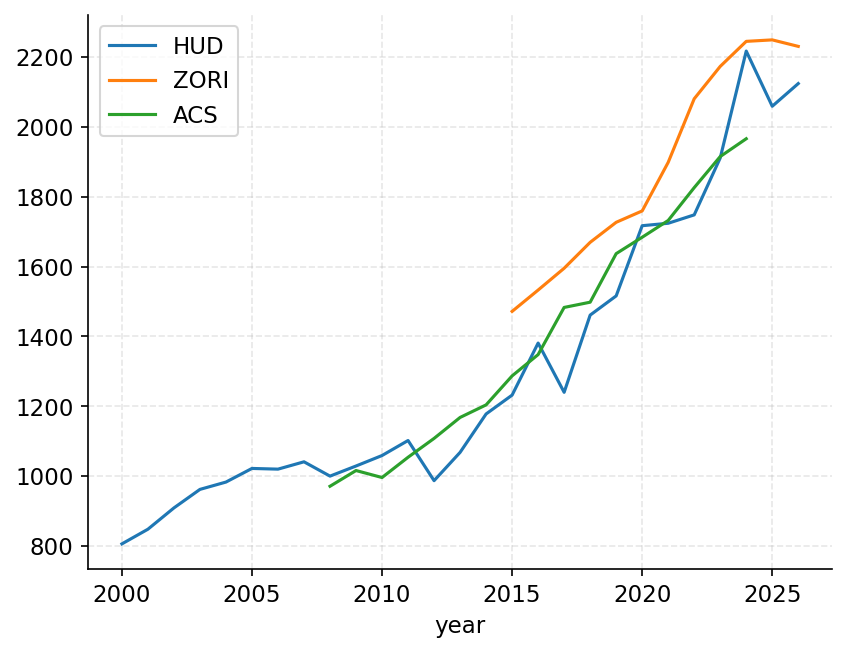

In [48]:
combined_rent_df = pd.DataFrame({
    'HUD':fmr,
    'ZORI':zori_annual,
    'ACS':acs_rent_df['median_gross_rent']
})

combined_rent_df.to_clipboard()

combined_rent_df.plot()

## 6. ACS Housing Cost Burden — Boulder County Renters

HUD defines cost-burdened as spending >30% of gross income on housing;
severely cost-burdened as >50%. These figures establish the baseline
housing stress context for Boulder County renters — the same population
that includes most tipped service workers.

Source: ACS 1-Year, Table B25070


In [ ]:
burden_by_year = {}
for year in acs_years:
    url = (f"https://api.census.gov/data/{year}/acs/acs1"
           f"?get=B25070_001E,B25070_007E,B25070_008E,B25070_009E,B25070_010E"
           f"&for=county:013&in=state:08")
    try:
        d       = json.loads(fetch(url))
        total   = int(d[1][0])
        b30_35  = int(d[1][1])
        b35_40  = int(d[1][2])
        b40_50  = int(d[1][3])
        b50plus = int(d[1][4])
        burden_by_year[year] = {
            "total_renters":      total,
            "cost_burdened":      b30_35 + b35_40 + b40_50 + b50plus,
            "severely_burdened":  b40_50 + b50plus,
            "pct_burdened":       (b30_35 + b35_40 + b40_50 + b50plus) / total,
            "pct_severely":       (b40_50 + b50plus) / total,
        }
    except Exception as e:
        print(f"  Burden {year}: {e}")

In [51]:
burden_df = pd.DataFrame(burden_by_year).T.sort_index()
burden_df.index.name = "year"

fmt = burden_df[["total_renters","cost_burdened","severely_burdened","pct_burdened","pct_severely"]].copy()
fmt["pct_burdened"] = fmt["pct_burdened"].map("{:.1%}".format)
fmt["pct_severely"] = fmt["pct_severely"].map("{:.1%}".format)
print("Boulder County Renter Cost Burden:")

burden_df[['pct_burdened','pct_severely']].to_clipboard()

print(fmt.to_string())

Boulder County Renter Cost Burden:
      total_renters  cost_burdened  severely_burdened pct_burdened pct_severely
year                                                                           
2008        41381.0        21366.0            14675.0        51.6%        35.5%
2009        42112.0        24642.0            17831.0        58.5%        42.3%
2010        45210.0        26375.0            18567.0        58.3%        41.1%
2011        40734.0        21914.0            16285.0        53.8%        40.0%
2012        47104.0        26927.0            20376.0        57.2%        43.3%
2013        45330.0        23755.0            18041.0        52.4%        39.8%
2014        48029.0        25076.0            18496.0        52.2%        38.5%
2015        49815.0        27483.0            19256.0        55.2%        38.7%
2016        43711.0        25141.0            18628.0        57.5%        42.6%
2017        49570.0        28497.0            19752.0        57.5%        39.8%
2018 

## 7. ACS Food Service Worker Earnings — Boulder County

ACS Table B24022 reports median annual earnings for **full-time, year-round**
civilian workers by detailed occupation and sex. Note: because many food
service workers are part-time or seasonal, these figures likely *overstate*
typical earnings relative to the full tipped-worker workforce.

Source: ACS 1-Year, Table B24022 (variables _024E male, _060E female)


In [55]:
# B24022_024E = Male: Food preparation and serving related occupations (median annual earnings)
# B24022_060E = Female: Food preparation and serving related occupations
occ_earnings = {}
for year in acs_years:
    url = (f"https://api.census.gov/data/{year}/acs/acs1"
           f"?get=B24022_024E,B24022_060E&for=county:013&in=state:08")
    try:
        d = json.loads(fetch(url))
        m = int(d[1][0])
        f = int(d[1][1])
        occ_earnings[year] = {
            "male_median_annual":    m,
            "female_median_annual":  f,
            "male_hourly_equiv":     round(m / 1820, 2),
            "female_hourly_equiv":   round(f / 1820, 2),
        }
    except Exception as e:
        print(f"  Occ {year}: {e}")

In [68]:
occ_df = pd.DataFrame(occ_earnings).T.sort_index()
occ_df.index.name = "year"
print("Boulder County Food Service Median Annual Earnings (full-time, year-round):")
occ_df[['male_median_annual','female_median_annual']].to_clipboard()
print(occ_df.to_string())

# Key reality check against industry claim
claimed_annual = 72_000
claimed_hourly = 35.00
m23 = occ_df.loc[2024, "male_median_annual"]
f23 = occ_df.loc[2024, "female_median_annual"]
print(f"\n--- The $40/hr Claim vs. ACS Data (2023) ---")
print(f"Industry claim:           ${claimed_annual:>7,}/yr  (${claimed_hourly:.2f}/hr)")
print(f"ACS male median:          ${m23:>7,}/yr  (${m23/2000:.2f}/hr)  -- {claimed_annual/m23:.1f}x below claim")
print(f"ACS female median:        ${f23:>7,}/yr  (${f23/2000:.2f}/hr)  -- {claimed_annual/f23:.1f}x below claim")

Boulder County Food Service Median Annual Earnings (full-time, year-round):
      male_median_annual  female_median_annual  male_hourly_equiv  female_hourly_equiv
year                                                                                  
2008             11799.0               22027.0               6.48                12.10
2009             40703.0               20909.0              22.36                11.49
2010             25888.0               21257.0              14.22                11.68
2011             27239.0               31045.0              14.97                17.06
2012             26436.0               18763.0              14.53                10.31
2013             21581.0               35472.0              11.86                19.49
2014             21116.0               26618.0              11.60                14.63
2015             25295.0               15939.0              13.90                 8.76
2016             22411.0               28574.0        

<Axes: xlabel='year'>

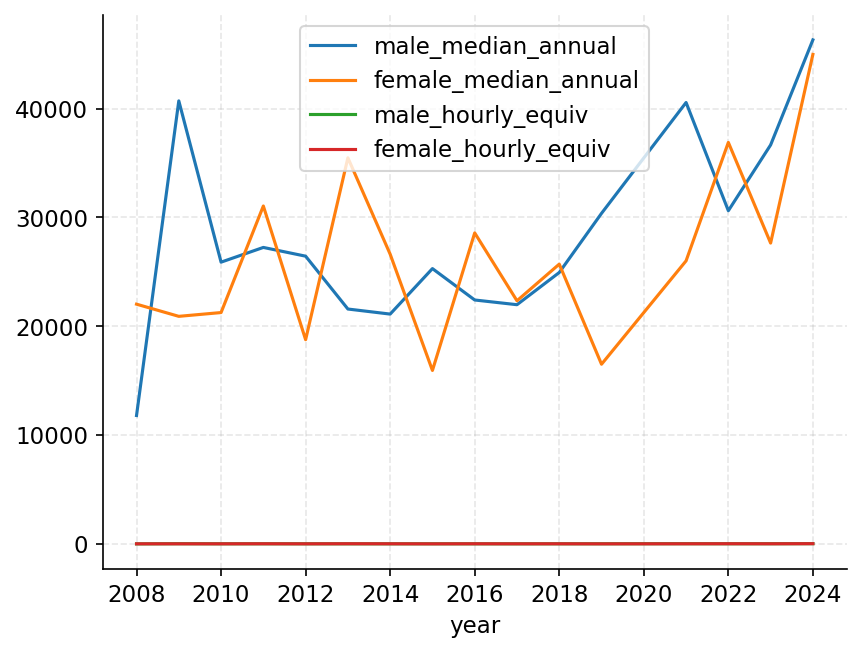

In [57]:
occ_df.plot()

## 7b. Benjamin's Scenario Table — ACS Rebuttal

Councilmember Benjamin's March 30 hotline email centers a scenario table built
on a "recent survey of Boulder restaurants" showing tipped workers earn \\$40/hr
in total compensation. Every scenario in that table — hours lost, pay cuts,
restaurant closures — is constructed from that baseline.

The American Community Survey provides a direct empirical counter. ACS B24022
reports median annual earnings of \\$36,654 for male full-time food service workers
in Boulder County in 2023 (\\$17.62/hr at 2080 hrs). The 2023 tipped minimum wage
was \\$10.63/hr, implying tips of \\$6.99/hr at the median.

We project 2025 values (base = \\$13.80, tips = \\$6.99 assumed constant) and
run Benjamin's five scenarios under both his assumptions and the ACS-calibrated
baseline. The break-even hours loss — the point at which a wage increase becomes
a net negative — is shown for each assumption set.


In [12]:
# ── Benjamin rebuttal table ───────────────────────────────────────────────────
# Benjamin's assumption: $40/hr total comp, 35 hrs/wk
# ACS calibration: male median $36,654/yr (2023), base $10.63 → implied tips $6.99/hr
#                  projected to 2025: base $13.80, tips $6.99 → total $20.79/hr

ACS_TIPS_2023 = round(occ_df.loc[2023,'male_median_annual'] / 2080
                      - mw.loc[2023,'tipped_min_wage'], 2)
BASE_2025     = mw.loc[2025, 'tipped_min_wage']  # $13.80
NEXT_BASE     = 15.15                            # Option A 2026 increase
HOURS_STD     = 35                               # Benjamin's assumption
ACS_TOTAL     = BASE_2025 + ACS_TIPS_2023        # $/hr total comp, ACS-calibrated

print(f"ACS-implied tip income (2023 male median): ${ACS_TIPS_2023:.2f}/hr")
print(f"ACS-calibrated 2025 total comp (base + ACS tips): ${ACS_TOTAL:.2f}/hr")
print(f"Benjamin's claim:                                  $40.00/hr")
print(f"Ratio (claim / ACS):                               {40.00/ACS_TOTAL:.1f}x\n")

def annual(total_hrly, hours, weeks=52):
    return total_hrly * hours * weeks

def weekly(total_hrly, hours):
    return total_hrly * hours

# ── Scenarios ─────────────────────────────────────────────────────────────────
# Row = (description, base_wage, hours, note)
scenarios_rebuttal = [
    ("Today (baseline)",           BASE_2025,  HOURS_STD, ""),
    (f"Raise to ${NEXT_BASE:.2f}, keep hours", NEXT_BASE,  HOURS_STD, ""),
    (f"Raise to ${NEXT_BASE:.2f}, lose 5 hrs", NEXT_BASE,  30,        ""),
    (f"Raise to ${NEXT_BASE:.2f}, lose 10 hrs",NEXT_BASE,  25,        ""),
    ("Freeze at $13.80, keep hrs", BASE_2025,  HOURS_STD, ""),
    ("Restaurant closes",          0,          0,         ""),
]

# Tips: Benjamin uses $26.20/hr (= $40 - $13.80), ACS uses $6.99/hr
BENJ_TIPS = 40.00 - BASE_2025   # $26.20/hr
ACS_TIPS  = ACS_TIPS_2023       # $6.99/hr

header = (f"{'Scenario':<35} "
          f"{'Benj $/hr':>9}  {'Benj Wkly':>10}  {'Benj Annual':>11}  {'Benj vs Today':>13}  ||  "
          f"{'ACS $/hr':>8}  {'ACS Wkly':>9}  {'ACS Annual':>10}  {'ACS vs Today':>12}")
print(header)
print("-" * len(header))

benj_today = annual(BASE_2025 + BENJ_TIPS, HOURS_STD)
acs_today  = annual(BASE_2025 + ACS_TIPS,  HOURS_STD)

for desc, base, hrs, _ in scenarios_rebuttal:
    if base == 0:
        benj_total = 0; acs_total = 0
        benj_wk = 0;    acs_wk = 0
        benj_ann = 0;   acs_ann = 0
    else:
        benj_total = base + BENJ_TIPS
        acs_total  = base + ACS_TIPS
        benj_wk = weekly(benj_total, hrs)
        acs_wk  = weekly(acs_total, hrs)
        benj_ann = annual(benj_total, hrs)
        acs_ann  = annual(acs_total, hrs)

    benj_delta = benj_ann - benj_today
    acs_delta  = acs_ann  - acs_today

    def fmt_d(v):
        return f"${v:+,.0f}" if v != 0 else "  baseline"

    print(f"{desc:<35} "
          f"{'$'+f'{benj_total:.2f}' if base>0 else '—':>9}  "
          f"{'$'+f'{benj_wk:,.0f}' if base>0 else '—':>10}  "
          f"{'$'+f'{benj_ann:,.0f}' if base>0 else '$0':>11}  "
          f"{fmt_d(benj_delta) if base>0 else '-$72,800':>13}  ||  "
          f"{'$'+f'{acs_total:.2f}' if base>0 else '—':>8}  "
          f"{'$'+f'{acs_wk:,.0f}' if base>0 else '—':>9}  "
          f"{'$'+f'{acs_ann:,.0f}' if base>0 else '$0':>10}  "
          f"{fmt_d(acs_delta) if base>0 else f'-${acs_today:,.0f}':>12}")

# ── Break-even hours calculation ──────────────────────────────────────────────
print("\n── Break-even hours loss (raise barely worth it) ──")
print("Workers are better off with the raise as long as hours stay above this threshold:\n")

for tips_label, tips in [("Benjamin ($26.20/hr tips)", BENJ_TIPS), ("ACS-calibrated ($6.99/hr tips)", ACS_TIPS)]:
    today_inc = annual(BASE_2025 + tips, HOURS_STD)
    # After raise: (NEXT_BASE + tips) * new_hours * 52 = today_inc
    be_hours = today_inc / ((NEXT_BASE + tips) * 52)
    hrs_loss = HOURS_STD - be_hours
    print(f"  {tips_label}")
    print(f"    Break-even: {be_hours:.1f} hrs/wk  (can only lose {hrs_loss:.1f} hrs before raise is a net loss)")
    print()

print("INTERPRETATION:")
print(f"  Benjamin's scenario: workers are better off with the raise unless they lose >"
      f" {HOURS_STD - annual(BASE_2025+BENJ_TIPS,HOURS_STD)/((NEXT_BASE+BENJ_TIPS)*52):.1f} hrs/wk")
print(f"  ACS scenario:        workers are better off with the raise unless they lose >"
      f" {HOURS_STD - annual(BASE_2025+ACS_TIPS,HOURS_STD)/((NEXT_BASE+ACS_TIPS)*52):.1f} hrs/wk")
print()
print(f"  The higher the tips, the more hours must be lost for the raise to turn negative.")
print(f"  Benjamin's $40/hr figure inflates the break-even, making the freeze look safer.")
print(f"  Under ACS numbers, a worker would need to lose >{HOURS_STD - annual(BASE_2025+ACS_TIPS,HOURS_STD)/((NEXT_BASE+ACS_TIPS)*52):.1f} hrs — "
      f"still a large cut — for the raise to hurt.")

ACS-implied tip income (2023 male median): $6.99/hr
ACS-calibrated 2025 total comp (base + ACS tips): $20.79/hr
Benjamin's claim:                                  $40.00/hr
Ratio (claim / ACS):                               1.9x

Scenario                            Benj $/hr   Benj Wkly  Benj Annual  Benj vs Today  ||  ACS $/hr   ACS Wkly  ACS Annual  ACS vs Today
----------------------------------------------------------------------------------------------------------------------------------------
Today (baseline)                       $40.00      $1,400      $72,800       baseline  ||    $20.79       $728     $37,838      baseline
Raise to $15.15, keep hours            $41.35      $1,447      $75,257        $+2,457  ||    $22.14       $775     $40,295       $+2,457
Raise to $15.15, lose 5 hrs            $41.35      $1,240      $64,506        $-8,294  ||    $22.14       $664     $34,538       $-3,299
Raise to $15.15, lose 10 hrs           $41.35      $1,034      $53,755       $-19,045

## 8. Census County Business Patterns — Food Service Sector

CBP (NAICS 722: Restaurants & Other Eating Places) provides annual establishment
counts, employment, and payroll for Boulder County. This tests the empirical claim
that restaurants face a structural crisis requiring wage relief.

Source: Census County Business Patterns API (2012–2022)


In [ ]:
cbp_data = {}
for year in range(2012, 2025):
    naics_var = "NAICS2017" if year >= 2017 else "NAICS2012"
    url = (f"https://api.census.gov/data/{year}/cbp"
           f"?get={naics_var},ESTAB,EMP,PAYANN"
           f"&for=county:013&in=state:08&{naics_var}=722")
    try:
        d = json.loads(fetch(url))
        cbp_data[year] = {
            "establishments": int(d[1][1]),
            "employment":     int(d[1][2]),
            "payroll_000s":   int(d[1][3]),
        }
    except Exception as e:
        print(f"  CBP {year}: {e}")

In [63]:
cbp = pd.DataFrame(cbp_data).T.sort_index()
cbp.index.name = "year"
cbp["avg_pay"]           = (cbp["payroll_000s"] * 1000 / cbp["employment"]).round(0)
cbp["avg_hourly_equiv"]  = (cbp["avg_pay"] / 2080).round(2)
cbp[['establishments','employment','avg_pay']].to_clipboard()

print("Boulder County Food Service (NAICS 722):")
print(cbp.to_string())
print(f"\nEstablishments: 2019={cbp.loc[2019,'establishments']}  2022={cbp.loc[2022,'establishments']}  change={cbp.loc[2022,'establishments']-cbp.loc[2019,'establishments']:+d}")
print(f"Employment:     2019={cbp.loc[2019,'employment']:,}  2022={cbp.loc[2022,'employment']:,}  change={cbp.loc[2022,'employment']-cbp.loc[2019,'employment']:+,}")

Boulder County Food Service (NAICS 722):
      establishments  employment  payroll_000s  avg_pay  avg_hourly_equiv
year                                                                     
2012             800       14573        229253  15731.0              7.56
2013             806       15238        256868  16857.0              8.10
2014             816       15994        279672  17486.0              8.41
2015             809       16559        298512  18027.0              8.67
2016             817       17706        323632  18278.0              8.79
2017             872       18213        347106  19058.0              9.16
2018             888       19136        379515  19833.0              9.54
2019             858       17999        384660  21371.0             10.27
2020             858       17687        294650  16659.0              8.01
2021             838       13873        380841  27452.0             13.20
2022             871       16248        437070  26900.0             12.

## 9. Affordability Gap Analysis

Working backward from rent: a household spending exactly 30% of gross income on
housing needs to earn **(monthly rent × 40)** annually, or **(monthly rent / 52 × 12 / 0.30 / 2080)**
per hour at full-time work. We compute this threshold for each rent series
and compare to each policy scenario.


In [14]:
def wage_to_afford(monthly_rent, hours_per_year=2080):
    annual_needed = monthly_rent * 12 / 0.30
    return annual_needed / hours_per_year

# Current benchmarks
rents = {
    "HUD 2BR FMR (2026)":         fmr[2026],
    "ACS median gross rent (2023)": acs_rent_df.loc[2023, "median_gross_rent"],
    "Zillow ZORI (2025 avg)":      float(zori_annual[2025]),
}

print("Hourly wage required to afford rent (30% rule):")
for lbl, r in rents.items():
    print(f"  {lbl:<40}: ${r:,.0f}/mo  ->  need ${wage_to_afford(r):.2f}/hr")

ref_rent   = acs_rent_df.loc[2023, "median_gross_rent"]
ref_needed = wage_to_afford(ref_rent)

print(f"\nAffordability gap by scenario (vs. ACS median rent ${ref_rent:,}/mo, need ${ref_needed:.2f}/hr):\n")
header = f"{'Scenario':<45}  {'2025':>6}  {'2026':>6}  {'2030':>6}  {'2030 gap':>10}"
print(header)
print("-" * len(header))
for opt, sc in scenarios.items():
    tw25 = sc.loc[2025, "tipped"]
    tw26 = sc.loc[2026, "tipped"]
    tw30 = sc.loc[2030, "tipped"]
    gap30 = ref_needed - tw30
    print(f"  {labels[opt]:<43}  ${tw25:.2f}   ${tw26:.2f}   ${tw30:.2f}   ${gap30:+.2f}/hr")

Hourly wage required to afford rent (30% rule):
  HUD 2BR FMR (2026)                      : $2,124/mo  ->  need $40.85/hr
  ACS median gross rent (2023)            : $1,915/mo  ->  need $36.83/hr
  Zillow ZORI (2025 avg)                  : $2,259/mo  ->  need $43.44/hr

Affordability gap by scenario (vs. ACS median rent $1,915/mo, need $36.83/hr):

Scenario                                         2025    2026    2030    2030 gap
---------------------------------------------------------------------------------
  Option A: Keep current offset ($3.02)        $13.80   $15.15   $17.84   $+18.99/hr
  Option B: Scale offset with full wage        $13.80   $14.91   $17.11   $+19.72/hr
  Option C: Freeze tipped through 2029         $13.80   $13.80   $15.64   $+21.19/hr
  Option D: Offset = 20% of full wage          $13.46   $14.54   $16.69   $+20.14/hr


## 10. Figure 1 — Tipped Wage vs. Rent: Indexed Growth (2015=100)

The centerpiece chart. Indexes tipped wage, full minimum wage, ACS rent, and
ZORI to 2015=100 to show divergence over time.


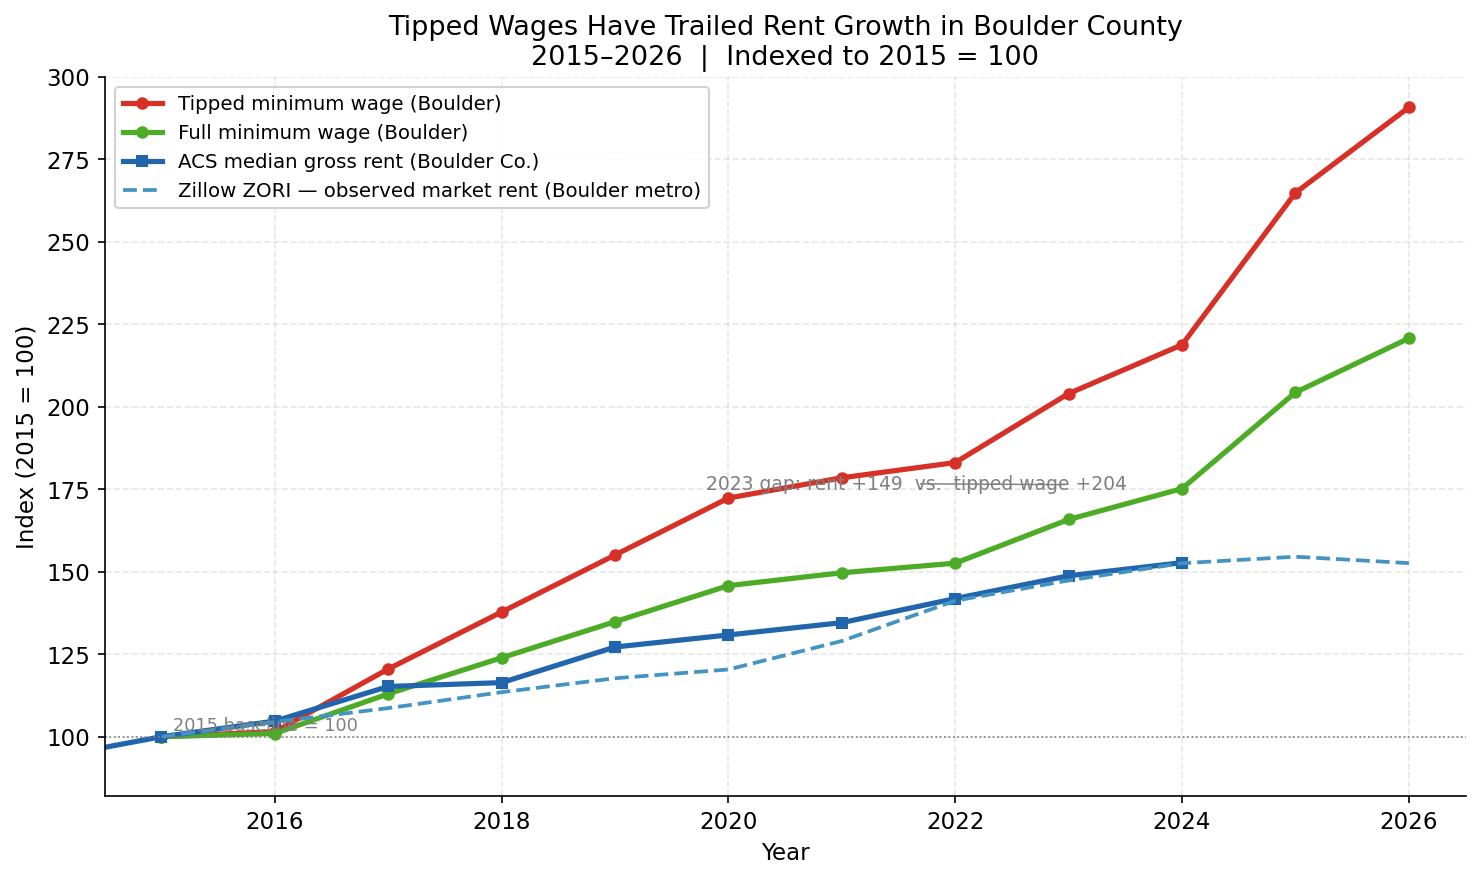

Saved: fig1_wage_rent_indexed.png


In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
BASE_YR = 2015

def idx(series, base=BASE_YR):
    return series / series.loc[base] * 100

tw_yrs  = sorted(mw.index)
tw_idx  = idx(mw.loc[tw_yrs, "tipped_min_wage"])
fw_idx  = idx(mw.loc[tw_yrs, "full_min_wage"])
acs_yrs = sorted(acs_rent_df.index)
acs_idx = idx(acs_rent_df.loc[acs_yrs, "median_gross_rent"])
z_yrs   = sorted(zori_annual.index)
z_idx   = idx(zori_annual.loc[z_yrs])

ax.plot(tw_yrs,  tw_idx.values,  color=C_TIPPED, lw=2.5, marker="o", ms=5,
        label="Tipped minimum wage (Boulder)")
ax.plot(tw_yrs,  fw_idx.values,  color=C_FULL,   lw=2.5, marker="o", ms=5,
        label="Full minimum wage (Boulder)")
ax.plot(acs_yrs, acs_idx.values, color=C_RENT,   lw=2.5, marker="s", ms=5,
        label="ACS median gross rent (Boulder Co.)")
ax.plot(z_yrs,   z_idx.values,   color="#4393c3", lw=1.8, ls="--",
        label="Zillow ZORI — observed market rent (Boulder metro)")

ax.axhline(100, color=C_GRAY, lw=0.8, ls=":")
ax.text(BASE_YR + 0.1, 101.8, "2015 baseline = 100", color=C_GRAY, fontsize=8.5)

# Annotate divergence gap in 2023
tw_23  = tw_idx.loc[2023]
acs_23 = acs_idx.loc[2023]
ax.annotate(
    f"2023 gap: rent +{acs_23:.0f}  vs.  tipped wage +{tw_23:.0f}",
    xy=(2023, (acs_23 + tw_23) / 2),
    xytext=(2019.8, 175),
    fontsize=9, color=C_GRAY,
    arrowprops=dict(arrowstyle="-", color=C_GRAY, lw=0.7),
)

ax.set_xlim(2014.5, 2026.5)
ax.set_ylim(82, 300)
ax.set_xlabel("Year")
ax.set_ylabel("Index (2015 = 100)")
ax.set_title("Tipped Wages Have Trailed Rent Growth in Boulder County\n"
             "2015–2026  |  Indexed to 2015 = 100")
ax.legend(loc="upper left", fontsize=9.5, framealpha=0.9)

plt.tight_layout()
plt.savefig("fig1_wage_rent_indexed.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig1_wage_rent_indexed.png")

## 11. Figure 2 — The $40/hr Claim vs. ACS Reality

Horizontal bar chart comparing the industry survey figure to actual ACS
earnings and rent-affordability thresholds — on a single comparable scale.


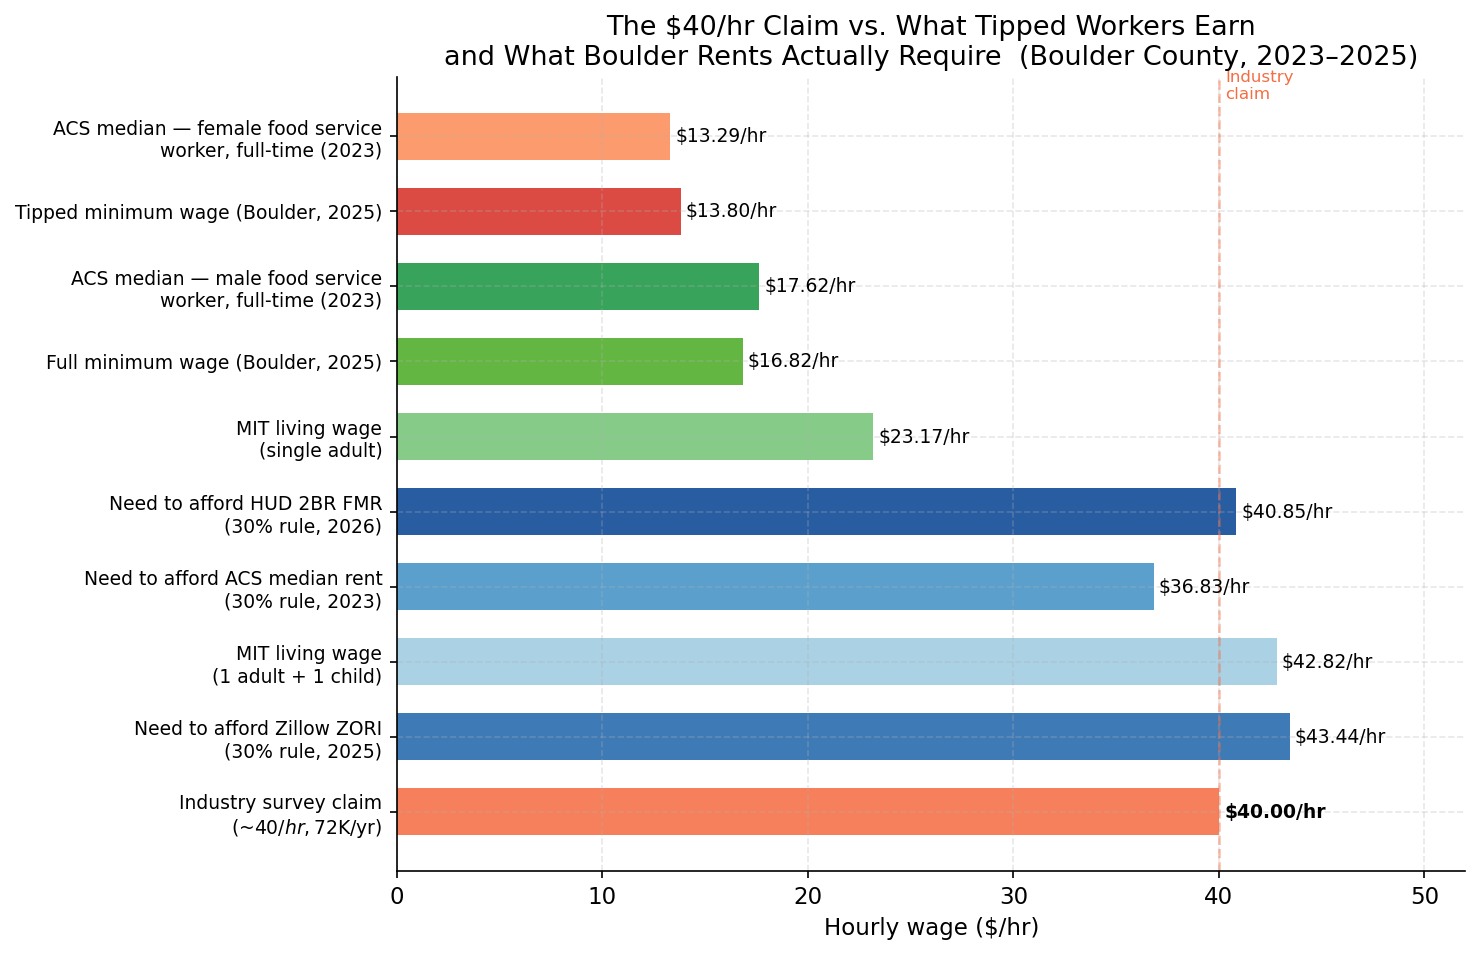

Saved: fig2_claim_vs_reality.png


In [23]:
# MIT Living Wage, Boulder County (2024) — from livingwage.mit.edu/counties/08013
MIT_SINGLE      = 23.17  # 1 adult, no children
MIT_ADULT_CHILD = 42.82  # 1 adult, 1 child

claimed_annual = 72_000
claimed_hourly = 40.00

fig, ax = plt.subplots(figsize=(10, 6.5))

acs_m_hr = occ_df.loc[2023, "male_hourly_equiv"]
acs_f_hr = occ_df.loc[2023, "female_hourly_equiv"]
tw_curr  = mw.loc[2025, "tipped_min_wage"]
fw_curr  = mw.loc[2025, "full_min_wage"]

bars = [
    # (label, value, color, bold)
    ("Industry survey claim\n(~$40/hr, $72K/yr)", claimed_hourly,             C_CLAIM,   True),
    ("Need to afford Zillow ZORI\n(30% rule, 2025)", wage_to_afford(float(zori_annual[2025])), C_RENT, False),
    ("MIT living wage\n(1 adult + 1 child)", MIT_ADULT_CHILD,                "#9ecae1", False),
    ("Need to afford ACS median rent\n(30% rule, 2023)", wage_to_afford(acs_rent_df.loc[2023,"median_gross_rent"]), "#4292c6", False),
    ("Need to afford HUD 2BR FMR\n(30% rule, 2026)", wage_to_afford(fmr[2026]),        "#084594", False),
    ("MIT living wage\n(single adult)",       MIT_SINGLE,                    "#74c476", False),
    (f"Full minimum wage (Boulder, 2025)",     fw_curr,                       C_FULL,    False),
    ("ACS median — male food service\nworker, full-time (2023)", acs_m_hr,   C_ACTUAL,  False),
    (f"Tipped minimum wage (Boulder, 2025)",   tw_curr,                       C_TIPPED,  False),
    ("ACS median — female food service\nworker, full-time (2023)", acs_f_hr, "#fc8d59", False),
]

lbls   = [b[0] for b in bars]
vals   = [b[1] for b in bars]
clrs   = [b[2] for b in bars]
bolds  = [b[3] for b in bars]

y = range(len(bars))
ax.barh(list(y), vals, color=clrs, height=0.62, alpha=0.87)
for i, (v, bold) in enumerate(zip(vals, bolds)):
    fw = "bold" if bold else "normal"
    ax.text(v + 0.25, i, f"${v:.2f}/hr", va="center", fontsize=9, fontweight=fw)

ax.set_yticks(list(y))
ax.set_yticklabels(lbls, fontsize=9)
ax.set_xlabel("Hourly wage ($/hr)")
ax.set_xlim(0, 52)
ax.set_title("The $40/hr Claim vs. What Tipped Workers Earn\n"
             "and What Boulder Rents Actually Require  (Boulder County, 2023–2025)")
ax.axvline(claimed_hourly, color=C_CLAIM, lw=1.2, ls="--", alpha=0.45)
ax.text(claimed_hourly + 0.3, len(bars) - 0.5, "Industry\nclaim", color=C_CLAIM, fontsize=8)

plt.tight_layout()
plt.savefig("fig2_claim_vs_reality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig2_claim_vs_reality.png")

In [67]:
pd.Series(data=vals,index=lbls).to_clipboard()

## 12. Figure 3 — Policy Scenario Projections (2025–2030)

Projected tipped wages under each council option against a dynamic
rent-affordability threshold (assuming 3.5%/yr rent growth from 2023 ACS baseline).
The shaded zone marks the "unaffordable" region above the threshold.


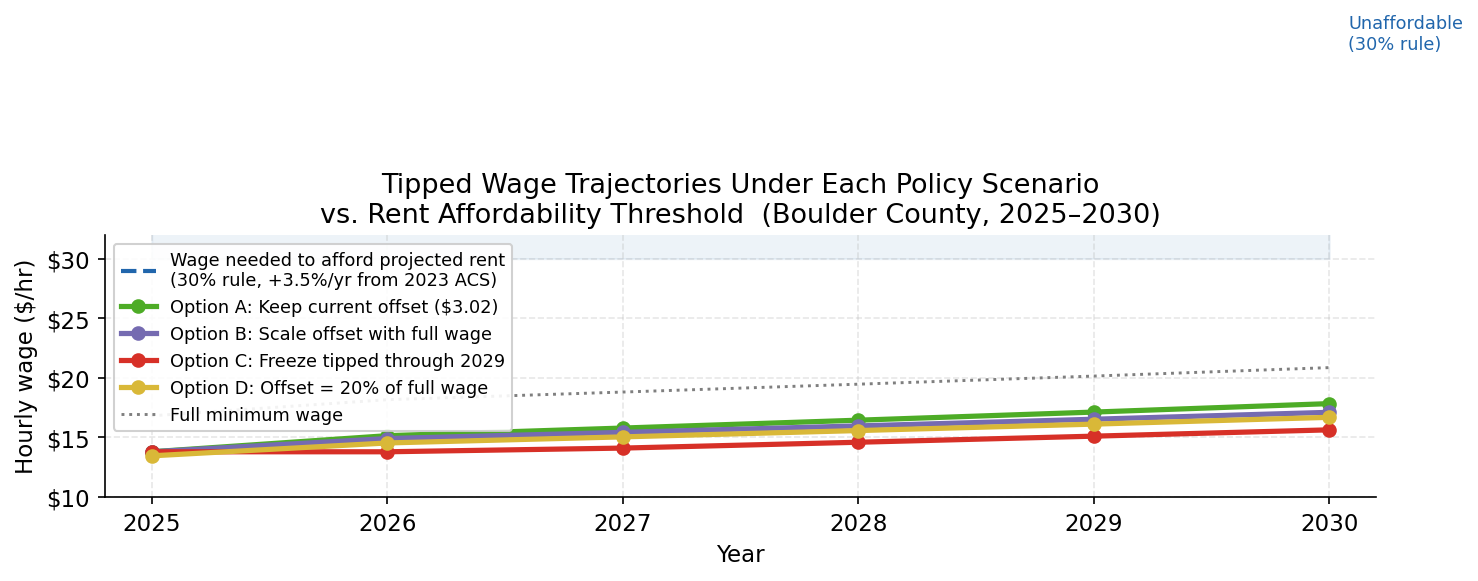

Saved: fig3_scenario_projections.png


In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

years_proj = sorted(full_wages.keys())

# Rent affordability threshold, projected forward at +3.5%/yr
base_rent   = acs_rent_df.loc[2023, "median_gross_rent"]
thresh_proj = {yr: wage_to_afford(base_rent * (1.035 ** (yr - 2023)))
               for yr in years_proj}

ax.fill_between(list(thresh_proj.keys()),
                list(thresh_proj.values()),
                [30] * len(years_proj),
                alpha=0.08, color=C_RENT)
ax.plot(list(thresh_proj.keys()), list(thresh_proj.values()),
        color=C_RENT, lw=2, ls="--",
        label="Wage needed to afford projected rent\n(30% rule, +3.5%/yr from 2023 ACS)")

sc_col = {"A": "#4dac26", "B": "#756bb1", "C": "#d73027", "D": "#d9b838"}
for opt, sc in scenarios.items():
    ax.plot(years_proj, sc.loc[years_proj, "tipped"].values,
            color=sc_col[opt], lw=2.5, marker="o", ms=6, label=labels[opt])

ax.plot(years_proj, [full_wages[y] for y in years_proj],
        color=C_GRAY, lw=1.4, ls=":", label="Full minimum wage")

ax.set_xlim(2024.8, 2030.2)
ax.set_ylim(10, 32)
ax.set_xlabel("Year")
ax.set_ylabel("Hourly wage ($/hr)")
ax.set_title("Tipped Wage Trajectories Under Each Policy Scenario\n"
             "vs. Rent Affordability Threshold  (Boulder County, 2025–2030)")
ax.legend(fontsize=8.5, loc="upper left", framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
ax.text(2030.08, thresh_proj[2030] + 0.4, "Unaffordable\n(30% rule)", color=C_RENT,
        fontsize=8.5, va="bottom")

plt.tight_layout()
plt.savefig("fig3_scenario_projections.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig3_scenario_projections.png")

## 16. Monte Carlo Simulation — Distributional Analysis

**Key uncertain parameters:**
- **Tip income per hour**: log-normal (right-skewed; a few high earners pull the mean up).
  Baseline: median \\$10/hr (moderate casual-dining estimate). Sensitivity shown at
  \\$4/hr (ACS-implied lower bound) and \\$26/hr (Benjamin's claim).
- **Hours worked per week**: truncated normal, mean 30 hrs, SD 6 (range 15–45).
  Benjamin uses 35; industry standard for tipped workers is 28–32.
- **Rent growth rate**: normal, mean 3.5%/yr, SD 1.5%, clipped [0%, 10%].

N = 8,000 simulations per scenario. Annual income = (base_wage + tip_income) × hours × 52.

The fan chart (Figure 5) shows the **median income trajectory** with shaded
25th–75th and 10th–90th percentile bands for each key scenario, overlaid on the
rent affordability threshold (wage needed for housing to consume ≤30% of income).


In [25]:
import numpy as np
from scipy.stats import truncnorm

np.random.seed(42)
N_SIMS = 8_000

# ── Parameter distributions ───────────────────────────────────────────────────

# Tip income: log-normal (mean, coefficient of variation)
def draw_lognormal(mean, cv, n):
    sigma2 = np.log(1 + cv**2)
    mu     = np.log(mean) - sigma2 / 2
    return np.random.lognormal(mu, np.sqrt(sigma2), n)

TIP_CONFIGS = {
    'ACS-implied ($4/hr)':          {'mean': 4.0,  'cv': 0.9},
    'Moderate / baseline ($10/hr)': {'mean': 10.0, 'cv': 0.7},
    "Benjamin's claim ($26/hr)":    {'mean': 26.2, 'cv': 0.3},
}

# Hours per week: truncated normal
HOURS_MEAN, HOURS_SD, HOURS_MIN, HOURS_MAX = 30.0, 6.0, 15.0, 45.0
a_h = (HOURS_MIN - HOURS_MEAN) / HOURS_SD
b_h = (HOURS_MAX - HOURS_MEAN) / HOURS_SD
hours_sim = truncnorm.rvs(a_h, b_h, loc=HOURS_MEAN, scale=HOURS_SD, size=N_SIMS)

# Rent growth: normal, clipped
rent_growth_sim = np.clip(
    np.random.normal(0.035, 0.015, N_SIMS), 0.0, 0.10
)

# Baseline tips draw (moderate / baseline config)
tips_sim = draw_lognormal(10.0, 0.7, N_SIMS)

print(f"Tip income draw (moderate baseline):  "
      f"mean=${tips_sim.mean():.2f}/hr  median=${np.median(tips_sim):.2f}/hr  "
      f"p90=${np.percentile(tips_sim,90):.2f}/hr")
print(f"Hours/wk draw:  "
      f"mean={hours_sim.mean():.1f}  median={np.median(hours_sim):.1f}  "
      f"p10={np.percentile(hours_sim,10):.1f}  p90={np.percentile(hours_sim,90):.1f}")
print(f"Rent growth draw:  "
      f"mean={rent_growth_sim.mean():.2%}  sd={rent_growth_sim.std():.2%}")

# ── Simulate annual income for each scenario and year ─────────────────────────
YEARS_MC = list(range(2025, 2033))
BASE_RENT_MC = acs_rent_df.loc[2023, 'median_gross_rent']  # $1,915/mo

# Collect base wages by scenario
base_wage_map = {
    'A':   {yr: scenarios['A'].loc[yr,'tipped'] for yr in scenarios['A'].index if yr in YEARS_MC},
    'C':   {yr: scenarios['C'].loc[yr,'tipped'] for yr in scenarios['C'].index if yr in YEARS_MC},
    'E1a': {yr: e1a_tw[yr] for yr in YEARS_MC if yr in e1a_tw},
    'E1b': {yr: e1b_tw[yr] for yr in YEARS_MC if yr in e1b_tw},
    'E2a': {yr: e2a_tw[yr] for yr in YEARS_MC if yr in e2a_tw},
}

income_mc = {}   # {scenario: {year: array(N_SIMS)}}
for sc, bw_map in base_wage_map.items():
    income_mc[sc] = {}
    for yr, bw in bw_map.items():
        income_mc[sc][yr] = (bw + tips_sim) * hours_sim * 52

# Rent affordability threshold distributions (annual income needed, 30% rule)
thresh_mc = {}
for yr in YEARS_MC:
    yrs_since = yr - 2023
    monthly_rent = BASE_RENT_MC * (1 + rent_growth_sim) ** yrs_since
    thresh_mc[yr] = monthly_rent * 12 / 0.30   # annual income needed

# ── Percentile helper ─────────────────────────────────────────────────────────
PCTS = [10, 25, 50, 75, 90]

def pct_series(mc_dict, yr_list, p):
    return [np.percentile(mc_dict[yr], p) for yr in yr_list if yr in mc_dict]

# ── Sensitivity: fraction unaffordable by scenario and tip assumption ─────────
print("\n── P(unaffordable) by scenario and tip assumption (2028) ──")
print(f"{'Scenario':<20}  {'ACS tips ($4)':>15}  {'Moderate ($10)':>15}  {'Benjamin ($26)':>15}")
print("-" * 72)
for sc, bw_map in base_wage_map.items():
    if 2028 not in bw_map:
        continue
    bw = bw_map[2028]
    rent_sample = thresh_mc[2028]
    row = f"{sc:<20}"
    for tip_cfg in ['ACS-implied ($4/hr)', 'Moderate / baseline ($10/hr)', "Benjamin's claim ($26/hr)"]:
        tc = TIP_CONFIGS[tip_cfg]
        tips_s = draw_lognormal(tc['mean'], tc['cv'], N_SIMS)
        income_s = (bw + tips_s) * hours_sim * 52
        p_unafford = np.mean(income_s < rent_sample)
        row += f"  {p_unafford:>14.1%}"
    print(row)

Tip income draw (moderate baseline):  mean=$10.05/hr  median=$8.25/hr  p90=$18.66/hr
Hours/wk draw:  mean=29.9  median=29.9  p10=22.3  p90=37.4
Rent growth draw:  mean=3.51%  sd=1.49%

── P(unaffordable) by scenario and tip assumption (2028) ──
Scenario                ACS tips ($4)   Moderate ($10)   Benjamin ($26)
------------------------------------------------------------------------
A                             100.0%           99.2%           90.1%
C                             100.0%           99.2%           92.8%
E1a                           100.0%           99.4%           92.9%
E1b                            99.9%           99.5%           93.2%
E2a                           100.0%           99.2%           91.3%


## 17. Figure 5 — Fan Chart: Annual Income Distribution by Policy Scenario

Median income trajectory (solid lines) with 25th–75th percentile (medium shading)
and 10th–90th percentile (light shading) Monte Carlo bands.
Overlay: rent affordability threshold with its own uncertainty band (dashed blue).
Vertical line at 2029: the freeze lifts under Option E.

**Read this chart as:** the gap between the rent threshold band and a scenario's
income band is the structural affordability shortfall — not just on average, but
across the distribution of hours and tip income that actual workers experience.

This is the recommended centerpiece figure for the op-ed.


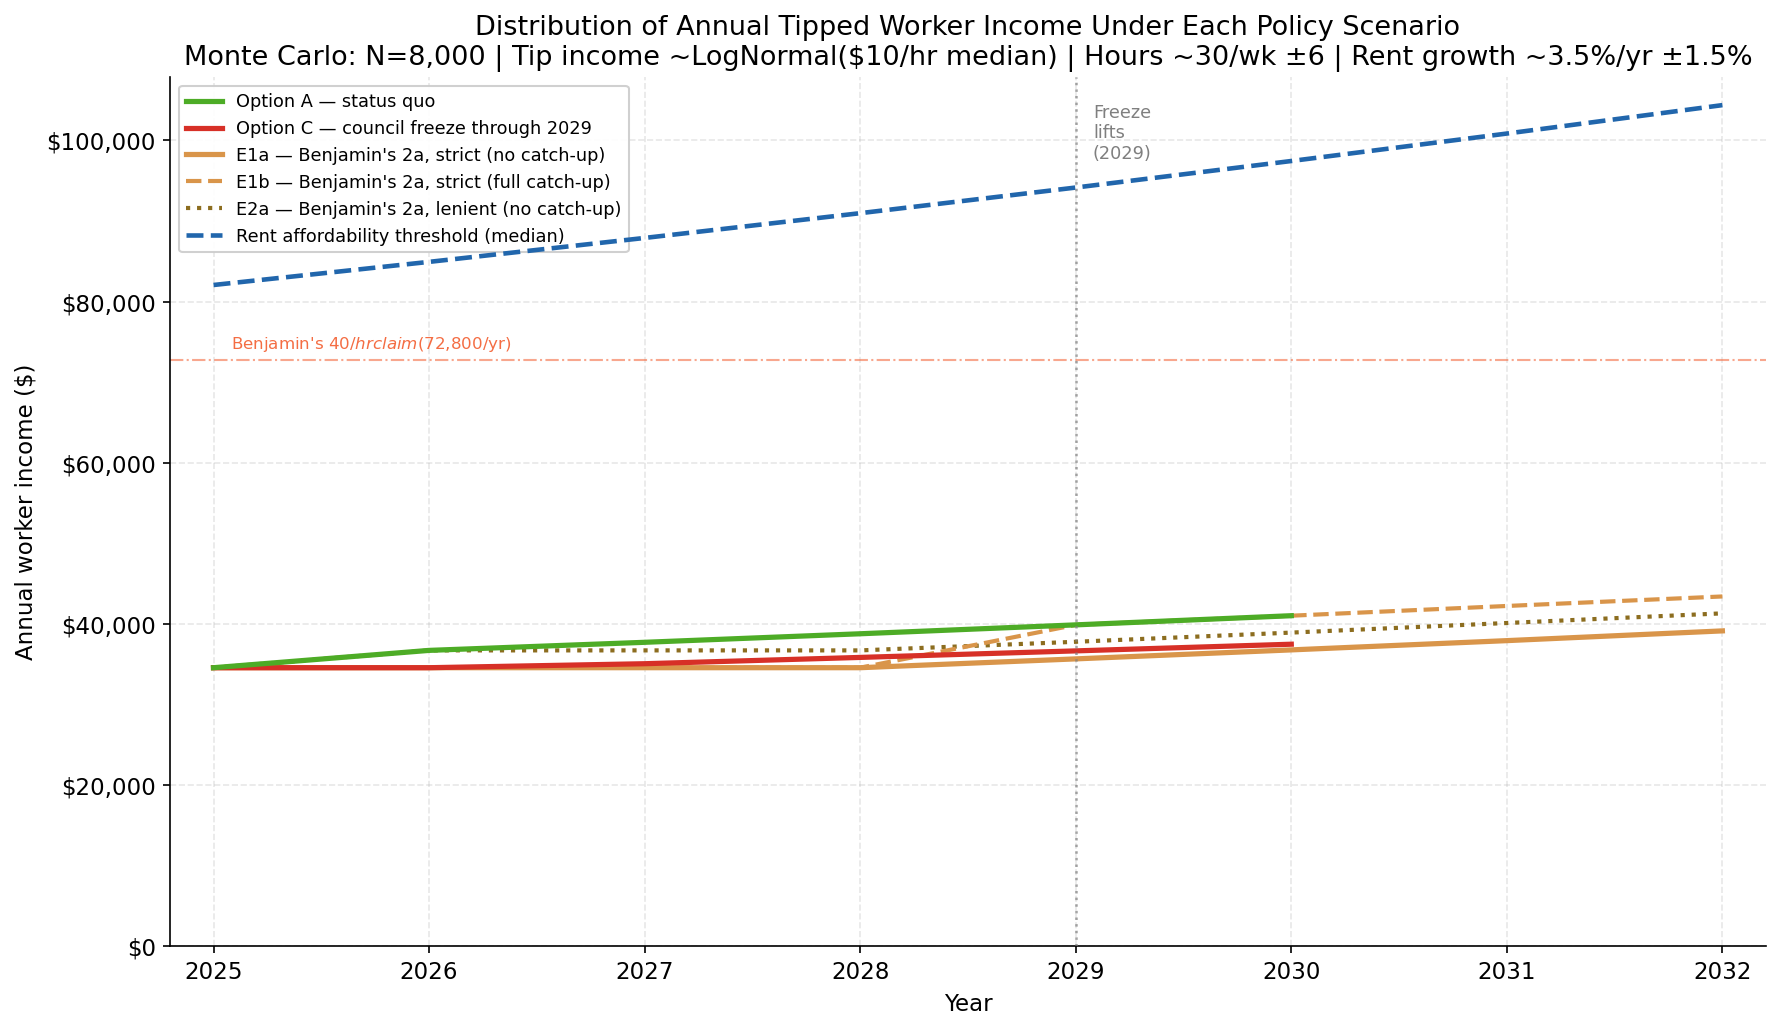

Saved: fig5_fan_chart_monte_carlo.png

OP-ED CENTERPIECE: This figure. Key talking points from the Monte Carlo:
  2026: Option A median income $36,701  |  E1a median $34,551  |  Threshold $84,922  |  % unaffordable: A=99%  E1a=99%
  2028: Option A median income $38,764  |  E1a median $34,551  |  Threshold $90,966  |  % unaffordable: A=99%  E1a=99%
  2030: Option A median income $41,005  |  E1a median $36,762  |  Threshold $97,441  |  % unaffordable: A=99%  E1a=100%


In [33]:
fig, ax = plt.subplots(figsize=(12, 7))

YEARS_PLOT = [yr for yr in YEARS_MC if yr <= 2032]

sc_style = {
    'A':   {'label': 'Option A — status quo',                       'color': C_FULL,    'lw': 2.5, 'ls': '-',  'zorder': 5},
    'C':   {'label': 'Option C — council freeze through 2029',       'color': C_TIPPED,  'lw': 2.5, 'ls': '-',  'zorder': 4},
    'E1a': {'label': "E1a — Benjamin's 2a, strict (no catch-up)",    'color': '#d9954a', 'lw': 2.5, 'ls': '-',  'zorder': 3},
    'E1b': {'label': "E1b — Benjamin's 2a, strict (full catch-up)",  'color': '#d9954a', 'lw': 2.0, 'ls': '--', 'zorder': 3},
    'E2a': {'label': "E2a — Benjamin's 2a, lenient (no catch-up)",   'color': '#8c6d1f', 'lw': 2.0, 'ls': ':',  'zorder': 2},
}

for sc, style in sc_style.items():
    if sc not in income_mc:
        continue
    yrs_avail = sorted(y for y in income_mc[sc] if y in YEARS_PLOT)
    if not yrs_avail:
        continue

    med   = [np.percentile(income_mc[sc][yr], 50) for yr in yrs_avail]
    p25   = [np.percentile(income_mc[sc][yr], 25) for yr in yrs_avail]
    p75   = [np.percentile(income_mc[sc][yr], 75) for yr in yrs_avail]
    # p10   = [np.percentile(income_mc[sc][yr], 10) for yr in yrs_avail]
    # p90   = [np.percentile(income_mc[sc][yr], 90) for yr in yrs_avail]

    ax.plot(yrs_avail, med, color=style['color'], lw=style['lw'], ls=style['ls'],
            label=style['label'], zorder=style['zorder'])
    # if style['ls'] == '-':   # only shade solid lines for clarity
        # ax.fill_between(yrs_avail, p25, p75, color=style['color'], alpha=0.13, zorder=1)
        # ax.fill_between(yrs_avail, p10, p90, color=style['color'], alpha=0.06, zorder=0)

# Rent threshold band
yrs_rent = sorted(thresh_mc.keys())
t_med = [np.percentile(thresh_mc[yr], 50) for yr in yrs_rent]
t_p25 = [np.percentile(thresh_mc[yr], 25) for yr in yrs_rent]
t_p75 = [np.percentile(thresh_mc[yr], 75) for yr in yrs_rent]

ax.plot(yrs_rent, t_med, color=C_RENT, lw=2.2, ls='--', label='Rent affordability threshold (median)', zorder=6)
# ax.fill_between(yrs_rent, t_p25, t_p75, color=C_RENT, alpha=0.12, zorder=1)

# Freeze-lifts annotation
ax.axvline(2029, color=C_GRAY, lw=1.2, ls=':', alpha=0.7, zorder=7)
ylim_max = ax.get_ylim()[1]
ax.text(2029.08, ylim_max * 0.97, "Freeze\nlifts\n(2029)", color=C_GRAY, fontsize=8.5,
        va='top', ha='left')

# Benjamin's $40/hr annual claim annotation
benj_annual = 40.0 * 35 * 52   # $72,800
ax.axhline(benj_annual, color=C_CLAIM, lw=1.0, ls='-.', alpha=0.6)
ax.text(2025.08, benj_annual + 800, "Benjamin's $40/hr claim ($72,800/yr)",
        color=C_CLAIM, fontsize=8, va='bottom')

ax.set_xlim(2024.8, 2032.2)
ax.set_ylim(0, max(benj_annual * 1.08, ax.get_ylim()[1]))
ax.set_xlabel("Year")
ax.set_ylabel("Annual worker income ($)")
ax.set_title(
    "Distribution of Annual Tipped Worker Income Under Each Policy Scenario\n"
    "Monte Carlo: N=8,000 | Tip income ~LogNormal($10/hr median) | Hours ~30/wk ±6 | "
    "Rent growth ~3.5%/yr ±1.5%"
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=8.5, loc='upper left', framealpha=0.92, ncol=1)

# Shading annotation
# ax.fill_between([2024.8, 2032.2], [0, 0], [1, 1],
#                 transform=ax.get_xaxis_transform(), color='white', alpha=0)
# ax.text(2031.5, ax.get_ylim()[1]*0.38, "Unaffordable\nregion\n(above threshold)", 
#         color=C_RENT, fontsize=8, ha='center', va='center', alpha=0.7)

plt.tight_layout()
plt.savefig("fig5_fan_chart_monte_carlo.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig5_fan_chart_monte_carlo.png")
print()
print("OP-ED CENTERPIECE: This figure. Key talking points from the Monte Carlo:")
yrs_key = [2026, 2028, 2030]
for yr in yrs_key:
    if yr not in income_mc['A'] or yr not in income_mc['E1a']:
        continue
    a_med  = np.median(income_mc['A'][yr])
    e1a_med= np.median(income_mc['E1a'][yr])
    t_med_yr = np.median(thresh_mc[yr])
    pct_unafford_a   = np.mean(income_mc['A'][yr]   < thresh_mc[yr])
    pct_unafford_e1a = np.mean(income_mc['E1a'][yr] < thresh_mc[yr])
    print(f"  {yr}: Option A median income ${a_med:,.0f}  |  E1a median ${e1a_med:,.0f}"
          f"  |  Threshold ${t_med_yr:,.0f}"
          f"  |  % unaffordable: A={pct_unafford_a:.0%}  E1a={pct_unafford_e1a:.0%}")

## 13. Figure 4 — Food Service Sector Health (CBP)

Two-panel chart: establishment counts and employment + average pay over time.
Tests whether the restaurant sector is in structural decline or recovering
from COVID in line with national patterns.


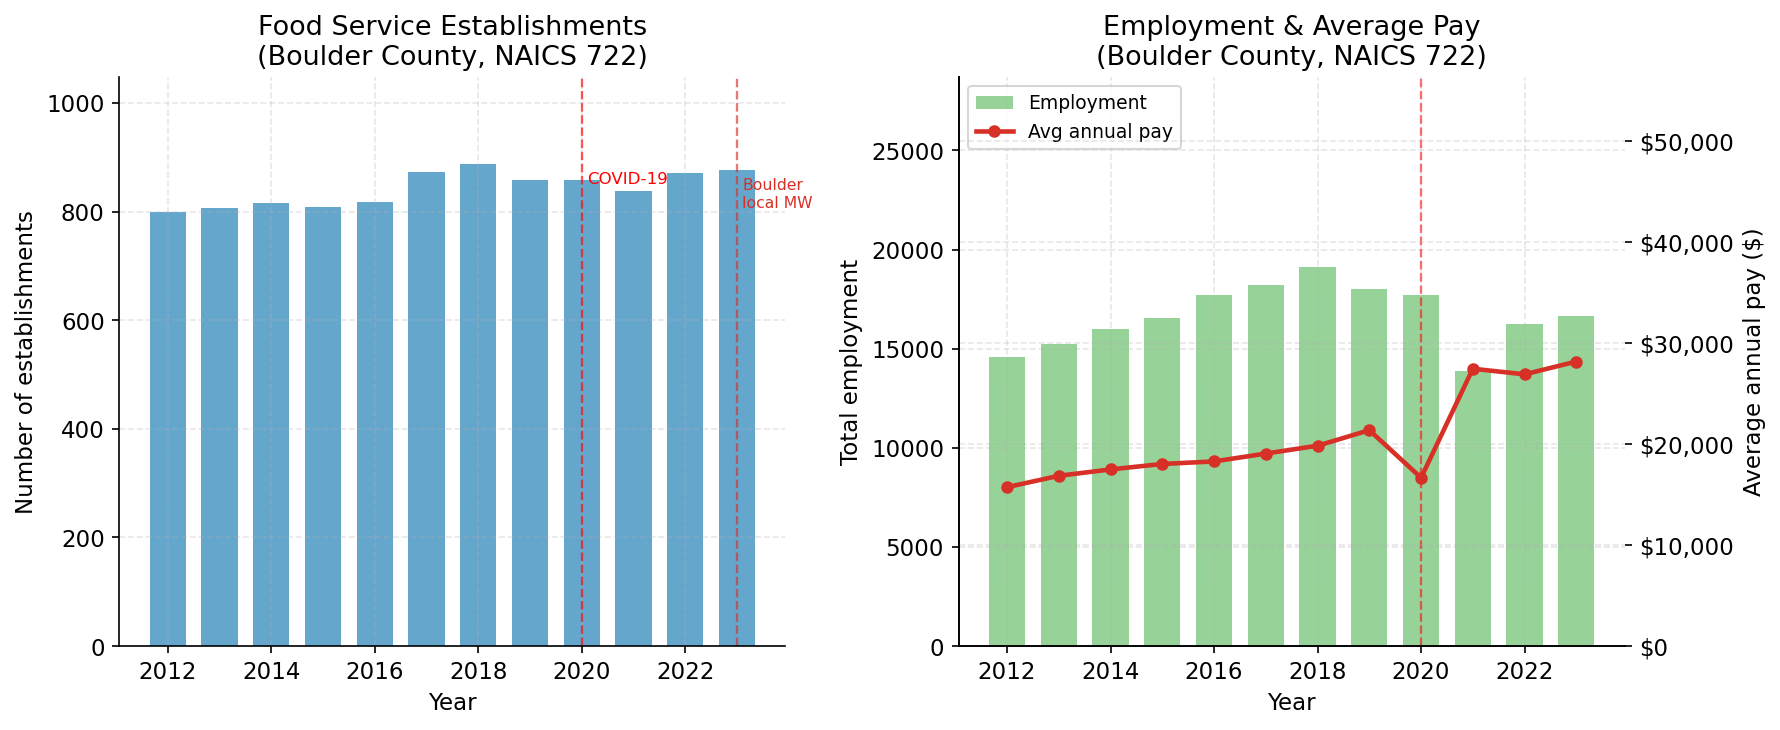

Saved: fig4_cbp_sector_health.png


In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
cbp_yrs = sorted(cbp.index)
bar_clr = "#4393c3"

# Panel 1: Establishments
ax1.bar(cbp_yrs, cbp.loc[cbp_yrs, "establishments"], color=bar_clr, alpha=0.82, width=0.7)
ax1.axvline(2020, color="red", lw=1.1, ls="--", alpha=0.65, label="COVID-19 (2020)")
ax1.axvline(2023, color=C_TIPPED, lw=1.1, ls="--", alpha=0.65, label="Boulder local MW begins")
peak = cbp.loc[cbp_yrs, "establishments"].max()
ax1.text(2020.1, peak * 0.96, "COVID-19", color="red",    fontsize=8)
ax1.text(2023.1, peak * 0.91, "Boulder\nlocal MW", color=C_TIPPED, fontsize=7.5)
ax1.set_xlabel("Year"); ax1.set_ylabel("Number of establishments")
ax1.set_title("Food Service Establishments\n(Boulder County, NAICS 722)")
ax1.set_ylim(0, peak * 1.18)

# Panel 2: Employment (bars) + Avg pay (line, right axis)
ax2r = ax2.twinx()
ax2.bar(cbp_yrs, cbp.loc[cbp_yrs, "employment"], color="#74c476", alpha=0.75, width=0.7, label="Employment")
ax2r.plot(cbp_yrs, cbp.loc[cbp_yrs, "avg_pay"], color=C_TIPPED, lw=2.2, marker="o", ms=5, label="Avg annual pay")
ax2.axvline(2020, color="red", lw=1.1, ls="--", alpha=0.55)
ax2.set_xlabel("Year")
ax2.set_ylabel("Total employment")
ax2r.set_ylabel("Average annual pay ($)")
ax2.set_title("Employment & Average Pay\n(Boulder County, NAICS 722)")
ax2.set_ylim(0, cbp.loc[cbp_yrs, "employment"].max() * 1.5)
ax2r.set_ylim(0, cbp.loc[cbp_yrs, "avg_pay"].max() * 2.0)
ax2r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
h1, l1 = ax2.get_legend_handles_labels()
h2, l2 = ax2r.get_legend_handles_labels()
ax2.legend(h1+h2, l1+l2, fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig("fig4_cbp_sector_health.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig4_cbp_sector_health.png")

## 14. Summary Statistics

In [28]:
print("=" * 68)
print("SUMMARY — TIPPED WAGES & AFFORDABILITY, BOULDER COUNTY")
print("=" * 68)

print("\n-- Wages (2025) --")
print(f"  Full minimum wage:           ${mw.loc[2025,'full_min_wage']:.2f}/hr")
print(f"  Tipped minimum wage:         ${mw.loc[2025,'tipped_min_wage']:.2f}/hr  (${mw.loc[2025,'annual_tipped']:,.0f}/yr at 2080 hrs)")
print(f"  Industry survey claim:       ${claimed_hourly:.2f}/hr  (${claimed_annual:,}/yr)")
print(f"  ACS male food svc median:    ${occ_df.loc[2023,'male_hourly_equiv']:.2f}/hr  (${occ_df.loc[2023,'male_median_annual']:,}/yr, 2023)")
print(f"  ACS female food svc median:  ${occ_df.loc[2023,'female_hourly_equiv']:.2f}/hr  (${occ_df.loc[2023,'female_median_annual']:,}/yr, 2023)")
print(f"  MIT living wage, 1 adult:    ${MIT_SINGLE:.2f}/hr (2024)")
print(f"  MIT living wage, adult+kid:  ${MIT_ADULT_CHILD:.2f}/hr (2024)")

print("\n-- Rent --")
print(f"  HUD 2BR FMR (2026):          ${fmr[2026]:,}/mo")
print(f"  ACS median gross rent (2023): ${acs_rent_df.loc[2023,'median_gross_rent']:,}/mo")
print(f"  Zillow ZORI (2025 avg):      ${zori_annual[2025]:,.0f}/mo")
pct_rent = (acs_rent_df.loc[2023,'median_gross_rent'] / acs_rent_df.loc[2015,'median_gross_rent'] - 1)*100
pct_tw   = (mw.loc[2025,'tipped_min_wage'] / mw.loc[2015,'tipped_min_wage'] - 1)*100
print(f"  Rent change 2015->2023 (ACS): +{pct_rent:.0f}%")
print(f"  Tipped wage change 2015->2025: +{pct_tw:.0f}%")

print("\n-- Affordability threshold (wage needed, 30% rule) --")
for lbl, r in rents.items():
    print(f"  {lbl:<42}: ${wage_to_afford(r):.2f}/hr")

print("\n-- Cost burden (Boulder Co. renters, 2023) --")
yr = 2023
print(f"  Total renter households:     {burden_df.loc[yr,'total_renters']:,}")
print(f"  Cost-burdened (30%+):        {burden_df.loc[yr,'cost_burdened']:,}  ({burden_df.loc[yr,'pct_burdened']:.1%})")
print(f"  Severely burdened (40%+):    {burden_df.loc[yr,'severely_burdened']:,}  ({burden_df.loc[yr,'pct_severely']:.1%})")

print("\n-- Food service sector (NAICS 722, CBP) --")
print(f"  Establishments 2019: {cbp.loc[2019,'establishments']}   2022: {cbp.loc[2022,'establishments']}   change: {cbp.loc[2022,'establishments']-cbp.loc[2019,'establishments']:+d}")
print(f"  Employment     2019: {cbp.loc[2019,'employment']:,}  2022: {cbp.loc[2022,'employment']:,}  change: {cbp.loc[2022,'employment']-cbp.loc[2019,'employment']:+,}")
print("=" * 68)

SUMMARY — TIPPED WAGES & AFFORDABILITY, BOULDER COUNTY

-- Wages (2025) --
  Full minimum wage:           $16.82/hr
  Tipped minimum wage:         $13.80/hr  ($28,704/yr at 2080 hrs)
  Industry survey claim:       $40.00/hr  ($72,000/yr)
  ACS male food svc median:    $17.62/hr  ($36,654.0/yr, 2023)
  ACS female food svc median:  $13.29/hr  ($27,640.0/yr, 2023)
  MIT living wage, 1 adult:    $23.17/hr (2024)
  MIT living wage, adult+kid:  $42.82/hr (2024)

-- Rent --
  HUD 2BR FMR (2026):          $2,124/mo
  ACS median gross rent (2023): $1,915/mo
  Zillow ZORI (2025 avg):      $2,259/mo
  Rent change 2015->2023 (ACS): +49%
  Tipped wage change 2015->2025: +165%

-- Affordability threshold (wage needed, 30% rule) --
  HUD 2BR FMR (2026)                        : $40.85/hr
  ACS median gross rent (2023)              : $36.83/hr
  Zillow ZORI (2025 avg)                    : $43.44/hr

-- Cost burden (Boulder Co. renters, 2023) --
  Total renter households:     53,256.0
  Cost-burdened (3

## 15. Methodology & Limitations

**Wage data:** ACS B24022 covers full-time, year-round workers only. Because many food
service workers are part-time or seasonal, ACS figures likely *overstate* typical
food service worker earnings relative to all tipped workers. The $40/hr industry
claim is from a restaurant-operator survey and covers total compensation including
tips — not workers' own reporting.

**Rent data:** Three sources are used intentionally, each capturing a different slice:
- *HUD FMR* (40th percentile, policy benchmark for modest housing)
- *ACS median gross rent* (actual renter-reported, includes utilities, most representative)
- *Zillow ZORI* (observed market listings, skews toward recently listed units)

**Scenario projections:** Post-2026 full wage growth assumed +3.5%/yr (near CPI).
Rent growth assumed +3.5%/yr from 2023 ACS baseline for projection purposes.
Option C math: freeze tipped at $13.80 through 2029, then grow offset proportionally.

**CBP data:** Counts first-quarter employment (March 12 pay period). May undercount
seasonal peak restaurant employment; treats all NAICS 722 establishments equally.

**MIT Living Wage:** Retrieved from livingwage.mit.edu/counties/08013. Should be
updated each year as MIT releases new figures.

**GitHub:** All code uses public data APIs with no authentication required. Reproduce
by running cells 0–14 in sequence.
